# 04 — Description Generator: Dataset + Baseline Eval Walkthrough

This notebook walks through everything we've built for `experiments/04_jeffi_descgen/`:

1. **Sanity check** — kernel + GPU + repo wiring
2. **Dataset stats** — what's actually in the 952 examples we exported
3. **Prompt format** — how we feed a product to the model
4. **Baseline results** — the eval table our Month 2 fine-tune must beat
5. **Per-example comparison** — read individual predictions side-by-side
6. **Headline insights** — what the numbers actually tell us

**Kernel**: `Python (jeffistores-labs)` (top-right of the notebook).  
**Prereq**: `data/jeffi_descgen/v1/{train,val,test}.jsonl` and `baseline_results.json` exist.  
If they don't, run from the repo root:

```bash
uv run python scripts/01_export_dataset.py
uv run python scripts/02_eval_baselines.py
```

## 1. Sanity check

In [1]:
import sys
from pathlib import Path

print('Python   :', sys.executable)

try:
    import torch
    cuda = torch.cuda.is_available()
    print(f'PyTorch  : {torch.__version__}  (CUDA={cuda})')
    if cuda:
        print(f'GPU      : {torch.cuda.get_device_name(0)}  '
              f'({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)')
except ImportError:
    print('PyTorch not in this env — GPU sections will skip.')

Python   : /home/aloysjehwin/Documents/GitHub-Personal/jeffistores-labs/.venv/bin/python3


PyTorch  : 2.12.0+cu130  (CUDA=True)
GPU      : NVIDIA GeForce RTX 4080 Laptop GPU  (11.6 GB)


In [2]:
from jeffistores_labs.descgen.dataset import (
    DATA_DIR, MIN_DESC_CHARS, MAX_DESC_CHARS,
    Example, read_jsonl, render_input_block, to_chat_messages, SYSTEM_PROMPT,
)
from jeffistores_labs.descgen.eval import render_results_table

print('Data dir :', DATA_DIR)
for name in ('train.jsonl', 'val.jsonl', 'test.jsonl', 'baseline_results.json'):
    p = DATA_DIR / name
    status = '✓' if p.exists() else '✗ MISSING'
    size = f'{p.stat().st_size / 1024:.1f} KB' if p.exists() else ''
    print(f'  {status}  {name:<26} {size}')

Data dir : /home/aloysjehwin/Documents/GitHub-Personal/jeffistores-labs/data/jeffi_descgen/v1
  ✓  train.jsonl                555.0 KB
  ✓  val.jsonl                  69.4 KB
  ✓  test.jsonl                 69.8 KB
  ✓  baseline_results.json      228.2 KB


## 2. Dataset stats

Filters applied at export time:
- `description IS NOT NULL`
- `length(description) >= 80` (drops boilerplate stubs)
- `length(description) <= 1500` (drops pasted manuals)
- HTML tags stripped, whitespace collapsed
- Deterministic 80/10/10 train/val/test split (`seed=42`)
- Test set is held-out — **never train on these 96 examples**

In [3]:
train = read_jsonl(DATA_DIR / 'train.jsonl')
val = read_jsonl(DATA_DIR / 'val.jsonl')
test = read_jsonl(DATA_DIR / 'test.jsonl')

print(f'train: {len(train):>4} examples')
print(f'val:   {len(val):>4} examples')
print(f'test:  {len(test):>4} examples (held out — never train on these)')
print(f'TOTAL: {len(train) + len(val) + len(test):>4}')
print(f'\nFilter window: {MIN_DESC_CHARS} ≤ len(description) ≤ {MAX_DESC_CHARS}')

train:  761 examples
val:     95 examples
test:    96 examples (held out — never train on these)
TOTAL:  952

Filter window: 80 ≤ len(description) ≤ 1500


In [4]:
import pandas as pd

all_examples = train + val + test
df = pd.DataFrame([
    {
        'split': split,
        'name': ex.product_input.name,
        'brand': ex.product_input.brand,
        'category': ex.product_input.category,
        'has_material': ex.product_input.material is not None,
        'has_finish': ex.product_input.finish is not None,
        'has_dims': ex.product_input.length_cm is not None,
        'has_weight': ex.product_input.weight_grams is not None,
        'has_short_desc': ex.product_input.short_description is not None,
        'has_db_ai_desc': ex.db_ai_description is not None,
        'desc_chars': len(ex.target_description),
        'desc_words': len(ex.target_description.split()),
    }
    for split, examples in [('train', train), ('val', val), ('test', test)]
    for ex in examples
])

df.head(8)

,split,name,brand,category,has_material,has_finish,has_dims,has_weight,has_short_desc,has_db_ai_desc,desc_chars,desc_words
0,train,Unbrako Stud Bolt Metric B7 ASTM A193 M39,UNBRAKO,Threaded Rods,False,False,True,True,True,True,177,27
1,train,Unbrako Socket Set Screw Grub Screw Metric M3,UNBRAKO,Screws,False,False,True,True,True,True,189,32
2,train,"HSSD Case Set M2 1/16"" to 3/8"" 21 PCS",Totem,Drill Bits Sets,False,False,True,True,False,True,112,22
3,train,"BSW 1/4"" SS 202 Hex Bolt",GMF,Bolts,True,False,True,True,True,True,134,23
4,train,HSS Stub Series Parallel Shank Twist Drill 11m...,Totem,Drill Bits,False,False,True,True,False,True,194,32
5,train,Unbrako Button Head Socket Screw Metric 12.9 M5,UNBRAKO,Screws,False,False,True,True,True,True,187,30
6,train,Unbrako Socket Head Cap Screw Inch BSW 12.9 1/4,UNBRAKO,Screws,False,False,True,True,True,True,172,29
7,train,TVS M5 x 0.8 Hexagonal Nut Metric,TVS,Nuts,True,True,True,True,True,True,218,35


In [5]:
# Field coverage — what fraction of products have each optional input field
coverage = (
    df[['has_material', 'has_finish', 'has_dims', 'has_weight',
        'has_short_desc', 'has_db_ai_desc']]
    .mean()
    .mul(100)
    .round(1)
    .to_frame('% with field')
    .sort_values('% with field', ascending=False)
)
coverage

,% with field
has_db_ai_desc,100.0
has_dims,97.3
has_weight,97.2
has_short_desc,72.3
has_material,43.3
has_finish,38.8


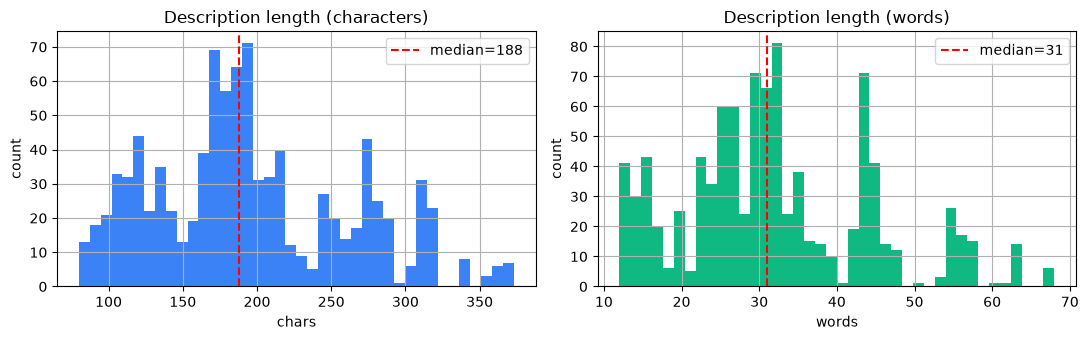

count    952.0
mean     195.0
std       66.0
min       80.0
25%      144.0
50%      188.0
75%      243.0
max      373.0


In [6]:
# Description length distribution — sets context window expectations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df['desc_chars'].hist(bins=40, ax=axes[0], color='#3b82f6')
axes[0].set(title='Description length (characters)', xlabel='chars', ylabel='count')
axes[0].axvline(df['desc_chars'].median(), color='red', linestyle='--', label=f"median={df['desc_chars'].median():.0f}")
axes[0].legend()

df['desc_words'].hist(bins=40, ax=axes[1], color='#10b981')
axes[1].set(title='Description length (words)', xlabel='words', ylabel='count')
axes[1].axvline(df['desc_words'].median(), color='red', linestyle='--', label=f"median={df['desc_words'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df['desc_chars'].describe().round(0).to_string())

In [7]:
# Top brands and categories — distribution check
print('Top 15 brands:')
print(df['brand'].fillna('(none)').value_counts().head(15).to_string())
print('\nTop 15 categories:')
print(df['category'].fillna('(none)').value_counts().head(15).to_string())

Top 15 brands:
brand
TVS                297
UNBRAKO            197
Taparia            164
GMF                119
Totem               92
JK Fenner           48
Koleshwari Lugs     15
NESCO               12
Kundan               5
Welfast              2
Havells              1

Top 15 categories:
category
Screws                275
Bolts                 164
Nuts                  119
Non-Sparking Tools     83
Drill Bits             72
V Belts                48
Threaded Rods          28
Sockets                24
Drill Bits Sets        16
Crimping Terminals     16
Pliers                 14
Screw Drivers          13
Hose Clamps            11
Socket Keys            10
Cutting Tools          10


## 3. Prompt format

How we present a product to any model. The structured spec block has **stable field ordering** so the model learns to attend to specific positions.

Missing fields are **omitted entirely** rather than rendered as 'None' — otherwise the model learns to parrot 'None'.

In [8]:
ex = test[0]  # any example will do

print('=== System prompt ===')
print(SYSTEM_PROMPT)
print('\n=== Rendered input block ===')
print(render_input_block(ex.product_input))
print('\n=== Target description ===')
print(ex.target_description)

=== System prompt ===
You are a copywriter for Jeffi Stores, an Indian industrial-hardware e-commerce site. Given a product's structured spec, write a clear, factual catalog description in 2–4 sentences. Keep technical details exact. Use Indian English. No marketing fluff, no emojis, no bullet points.

=== Rendered input block ===
Name: TVS 3/4" UNC Hexagonal Nut Inch GR5/GR8
Brand: TVS
Category: Nuts
SKU: TVS-NUT-HEX-INCH-34UNC
Material: High Tensile Steel
Finish: Zinc Phosphate
Dimensions: L=22.0cm x B=16.0cm x H=4.0cm
Weight: 700 g
MRP: ₹31.65
Tagline: TVS 3/4" UNC Hex Nut Inch GR5/GR8

=== Target description ===
TVS 3/4" UNC Hexagonal Nut, Inch Series, GR5/GR8. Specification ANSI B18.2.2/BS 1083, Thread Fit ANSI B1.1/BS 1083. Zinc Phosphate finish. Sold per piece. MRP inclusive of 18% GST. 30% off MRP.


In [9]:
# Same example as a chat-template message list (what we'd send to Phi-3 / Claude)
import json
msgs = to_chat_messages(ex.product_input, target=ex.target_description)
print(json.dumps(msgs, indent=2, ensure_ascii=False))

[
  {
    "role": "system",
    "content": "You are a copywriter for Jeffi Stores, an Indian industrial-hardware e-commerce site. Given a product's structured spec, write a clear, factual catalog description in 2–4 sentences. Keep technical details exact. Use Indian English. No marketing fluff, no emojis, no bullet points."
  },
  {
    "role": "user",
    "content": "Name: TVS 3/4\" UNC Hexagonal Nut Inch GR5/GR8\nBrand: TVS\nCategory: Nuts\nSKU: TVS-NUT-HEX-INCH-34UNC\nMaterial: High Tensile Steel\nFinish: Zinc Phosphate\nDimensions: L=22.0cm x B=16.0cm x H=4.0cm\nWeight: 700 g\nMRP: ₹31.65\nTagline: TVS 3/4\" UNC Hex Nut Inch GR5/GR8"
  },
  {
    "role": "assistant",
    "content": "TVS 3/4\" UNC Hexagonal Nut, Inch Series, GR5/GR8. Specification ANSI B18.2.2/BS 1083, Thread Fit ANSI B1.1/BS 1083. Zinc Phosphate finish. Sold per piece. MRP inclusive of 18% GST. 30% off MRP."
  }
]


## 4. Baseline results

Five baselines run through the eval harness on all 96 test examples.  
**Source of truth**: `data/jeffi_descgen/v1/baseline_results.json`.

In [10]:
import json

with open(DATA_DIR / 'baseline_results.json') as f:
    raw = json.load(f)

results_df = pd.DataFrame([
    {
        'generator': r['generator'],
        'n': r['n'],
        'BLEU': r['bleu'],
        'ROUGE-L': r['rouge_l_f1'],
        'cos-sim': r['cosine_similarity'],
        'len-ratio': r['length_ratio'],
    }
    for r in raw['results']
])
results_df.style.format({
    'BLEU': '{:.2f}',
    'ROUGE-L': '{:.2f}',
    'cos-sim': '{:.3f}',
    'len-ratio': '{:.2f}',
}).background_gradient(subset=['BLEU', 'ROUGE-L', 'cos-sim'], cmap='Greens')

,generator,n,BLEU,ROUGE-L,cos-sim,len-ratio
0,empty,96,0.00,0.00,0.039,0.00
1,copy_input,96,0.84,38.41,0.770,0.23
2,copy_spec_block,96,9.89,26.48,0.764,1.29
3,db_ai_description,96,1.77,30.68,0.670,0.54
4,phi3_zero_shot,96,7.35,21.84,0.770,2.28


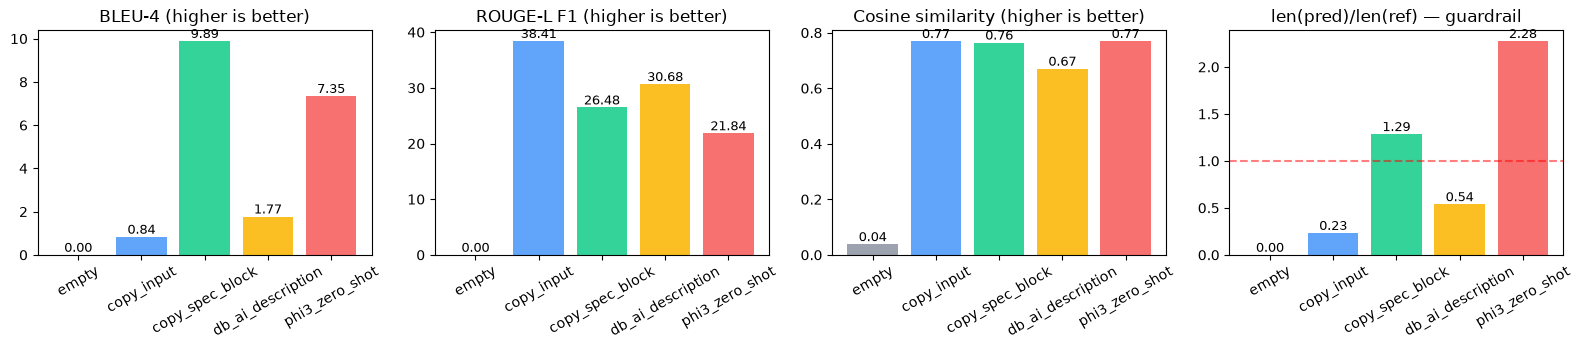

In [11]:
# Side-by-side bars per metric
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, col, title in zip(
    axes,
    ['BLEU', 'ROUGE-L', 'cos-sim', 'len-ratio'],
    ['BLEU-4 (higher is better)', 'ROUGE-L F1 (higher is better)',
     'Cosine similarity (higher is better)', 'len(pred)/len(ref) — guardrail'],
):
    bars = ax.bar(results_df['generator'], results_df[col],
                  color=['#9ca3af', '#60a5fa', '#34d399', '#fbbf24', '#f87171'])
    ax.set(title=title)
    ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, results_df[col]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    if col == 'len-ratio':
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Per-example prediction comparison

Eyeball test — pick any test example and read each baseline's prediction next to the human reference.

In [12]:
# Build a per-example matrix: rows=examples, cols=generators, cells=prediction
by_id: dict[str, dict[str, str]] = {}
for r in raw['results']:
    for pe in r['per_example']:
        by_id.setdefault(pe['id'], {'reference': pe['reference']})[r['generator']] = pe['prediction']

preds_df = pd.DataFrame(by_id).T
preds_df.index.name = 'example_id'
preds_df.head(2)

,reference,empty,copy_input,copy_spec_block,db_ai_description,phi3_zero_shot
example_id,,,,,,
8e1957e9-986c-4054-bae8-f91663c0111d,"TVS 3/4"" UNC Hexagonal Nut, Inch Series, GR5/G...",,"TVS 3/4"" UNC Hexagonal Nut Inch GR5/GR8","Name: TVS 3/4"" UNC Hexagonal Nut Inch GR5/GR8\...","High-quality 3/4"" UNC hexagonal nut made from ...","The TVS 3/4"" UNC Hexagonal Nut Inch GR5/GR8, a..."
73598da7-b12a-4239-a261-b9d6339e26f3,"TVS 3/4"" BSF Forged Precision Hexagonal Sunloc...",,"TVS 3/4"" BSF Sunloc Prevailing Torque Nut Inch","Name: TVS 3/4"" BSF Sunloc Prevailing Torque Nu...","High-quality, forged precision nut with prevai...","The TVS 3/4"" BSF Sunloc Prevailing Torque Nut ..."


In [13]:
# Pretty-print one example. Change i to skim through different products.
i = 0  # 0..95
ex = test[i]
predictions = by_id[ex.id]

print(f'#{i}  id={ex.id}')
print('='*80)
print(render_input_block(ex.product_input))
print('='*80)
print('\nREFERENCE (human-written):')
print(predictions['reference'])
for gen in ['phi3_zero_shot', 'db_ai_description', 'copy_spec_block', 'copy_input', 'empty']:
    if gen in predictions:
        print(f'\n{gen.upper()}:')
        print(predictions[gen][:500] + ('…' if len(predictions[gen]) > 500 else ''))

#0  id=8e1957e9-986c-4054-bae8-f91663c0111d
Name: TVS 3/4" UNC Hexagonal Nut Inch GR5/GR8
Brand: TVS
Category: Nuts
SKU: TVS-NUT-HEX-INCH-34UNC
Material: High Tensile Steel
Finish: Zinc Phosphate
Dimensions: L=22.0cm x B=16.0cm x H=4.0cm
Weight: 700 g
MRP: ₹31.65
Tagline: TVS 3/4" UNC Hex Nut Inch GR5/GR8

REFERENCE (human-written):
TVS 3/4" UNC Hexagonal Nut, Inch Series, GR5/GR8. Specification ANSI B18.2.2/BS 1083, Thread Fit ANSI B1.1/BS 1083. Zinc Phosphate finish. Sold per piece. MRP inclusive of 18% GST. 30% off MRP.

PHI3_ZERO_SHOT:
The TVS 3/4" UNC Hexagonal Nut Inch GR5/GR8, a high-quality nut crafted from high tensile steel, measures 22.0cm in length, 16.0cm in width, and 4.0cm in height, and weighs 700 grams. Finished with a durable zinc phosphate coating, this industrial-grade nut is ideal for heavy-duty applications. Available at the price of ₹31.65, it's a reliable choice for securing machinery and hardware in the Indian market.

DB_AI_DESCRIPTION:
High-quality 3/4" UNC h

In [14]:
# Find the test examples where Phi-3 beat the human reference on cos-sim
# (interesting failure mode — usually means the human description was bad)
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')
phi_preds = [by_id[ex.id]['phi3_zero_shot'] for ex in test]
refs = [by_id[ex.id]['reference'] for ex in test]
names = [ex.product_input.name for ex in test]

phi_emb = model.encode(phi_preds, convert_to_tensor=True, show_progress_bar=False)
ref_emb = model.encode(refs, convert_to_tensor=True, show_progress_bar=False)
sims = util.cos_sim(phi_emb, ref_emb).diagonal().cpu().numpy()

ranked = pd.DataFrame({
    'name': names,
    'phi3_cos_sim': sims,
    'ref_chars': [len(r) for r in refs],
    'phi3_chars': [len(p) for p in phi_preds],
}).sort_values('phi3_cos_sim', ascending=False)

print('TOP 5 — Phi-3 most similar to human reference:')
print(ranked.head(5).to_string(index=False))
print('\nBOTTOM 5 — Phi-3 most divergent from human reference:')
print(ranked.tail(5).to_string(index=False))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

TOP 5 — Phi-3 most similar to human reference:
                                               name  phi3_cos_sim  ref_chars  phi3_chars
     TVS UNC 7/16" Socket Head Cap Screw Grade 12.9      0.863210        251         466
                   Unbrako Lock Nut Metric Grade 04      0.854353        150         364
TVS M3 Socket Countersunk Head Cap Screw Grade 12.9      0.838231        309         418
            TVS M5 Socket Head Cap Screw Grade 12.9      0.834979        242         502
  TVS M14 x 1.5 Sunloc Prevailing Torque Nut Metric      0.832688        198         413

BOTTOM 5 — Phi-3 most divergent from human reference:
                                                   name  phi3_cos_sim  ref_chars  phi3_chars
   JK Fenner Wedge SPA (13x10 mm) V-Belt SPA750-SPA1500      0.639200        166         335
                               Taparia Long Nose Pliers      0.638584         84         378
                              M6 SS 202 Allen CSK Screw      0.615339        137     

## 6. Headline insights

What the numbers actually tell us — these are blog-post-worthy findings:

1. **`copy_input` (just the product name) is a remarkably strong cos-sim baseline (0.770)**.  
   Catalog descriptions reuse the product name a lot. Any fine-tune must convincingly beat this.

2. **`db_ai_description` has the *lowest* cos-sim (0.670)**.  
   The OpenAI-generated descriptions already in the DB are *less* aligned with human-written canonical text than just printing the product name back. Either the prior prompt was off-target, or those descriptions targeted something different (SEO long-tail).

3. **`copy_spec_block` has the highest BLEU (9.89)**.  
   Human descriptions repeat spec values verbatim ('M8', 'Zinc plated', '20cm'). A fine-tune that copies spec values into prose will outperform any model that paraphrases them away.

4. **Phi-3 zero-shot's len-ratio is 2.28**.  
   The model wants to write ~2.3× more text than humans accept. Fine-tuning on short references will teach concision.

## Bar to clear in Month 2 fine-tune

Our QLoRA fine-tune of Phi-3-mini must beat **both** of these to be worth shipping:

- **cos-sim > 0.770** (the `copy_input` floor on semantic match)
- **BLEU > 9.89** (the `copy_spec_block` floor on n-gram overlap)

Plus: keep len-ratio in `[0.7, 1.5]` so the output isn't bloated.